#Amit pawar
#PRN:25070126501
#This assignment Multiclass Sensor Dataset using

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/Multiclass_Sensor_Fault_Classification.csv')
df.head(10)

,Vibration_X,Vibration_Y,Current_Draw,Temperature,Acoustic_Level,Vibration_Magnitude,Current_Normalized,Temp_Scaled,Fault_Type
0,-0.003298,-4.955984,415.826466,84.569067,44.790209,4.955985,0.831653,0.704742,1
1,2.467468,-4.996698,355.343913,60.241849,28.418818,5.572736,0.710688,0.502015,3
2,0.626668,-0.277365,450.083712,67.190911,15.849123,0.685306,0.900167,0.559924,0
3,-4.166974,-4.707063,252.201227,91.672478,17.154257,6.286503,0.504402,0.763937,3
4,-3.144198,4.745326,452.250393,107.630603,78.404249,5.692459,0.904501,0.896922,1
5,-2.806718,-2.779348,439.598355,47.221880,50.032269,3.949993,0.879197,0.393516,3
6,-2.421357,-0.273353,247.284200,54.207680,75.356301,2.436738,0.494568,0.451731,3
7,0.654034,-4.388624,221.514492,113.073940,71.405841,4.437091,0.443029,0.942283,3
8,0.039658,0.220484,469.765407,77.851179,22.182622,0.224022,0.939531,0.648760,0
9,-2.968400,-1.200439,371.824131,37.896182,22.859914,3.201945,0.743648,0.315802,3


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Vibration_X          1000 non-null   float64
 1   Vibration_Y          1000 non-null   float64
 2   Current_Draw         1000 non-null   float64
 3   Temperature          1000 non-null   float64
 4   Acoustic_Level       1000 non-null   float64
 5   Vibration_Magnitude  1000 non-null   float64
 6   Current_Normalized   1000 non-null   float64
 7   Temp_Scaled          1000 non-null   float64
 8   Fault_Type           1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [ ]:
#pd.get_dummies(df, drop_first=True) Drop the first true values
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Vibration_X,Vibration_Y,Current_Draw,Temperature,Acoustic_Level,Vibration_Magnitude,Current_Normalized,Temp_Scaled,Fault_Type
0,-0.003298,-4.955984,415.826466,84.569067,44.790209,4.955985,0.831653,0.704742,1
1,2.467468,-4.996698,355.343913,60.241849,28.418818,5.572736,0.710688,0.502015,3
2,0.626668,-0.277365,450.083712,67.190911,15.849123,0.685306,0.900167,0.559924,0
3,-4.166974,-4.707063,252.201227,91.672478,17.154257,6.286503,0.504402,0.763937,3
4,-3.144198,4.745326,452.250393,107.630603,78.404249,5.692459,0.904501,0.896922,1


In [ ]:
x = df_encoded.drop('Fault_Type', axis=1)
y = df_encoded['Fault_Type']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)

y_dummy = dummy.predict(x_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy))


Dummy Accuracy: 0.575


In [ ]:
#Accuracy Score
#Precision Score
#Recall Score
#F1 Score
tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)

y_pred = tree.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, average='weighted'))
print("recall:", recall_score(y_test, y_pred, average='weighted'))
print("f1:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.995
precision: 0.9950431034482758
recall: 0.995
f1: 0.9949598021026592


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        24
           3       0.99      1.00      1.00       115

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



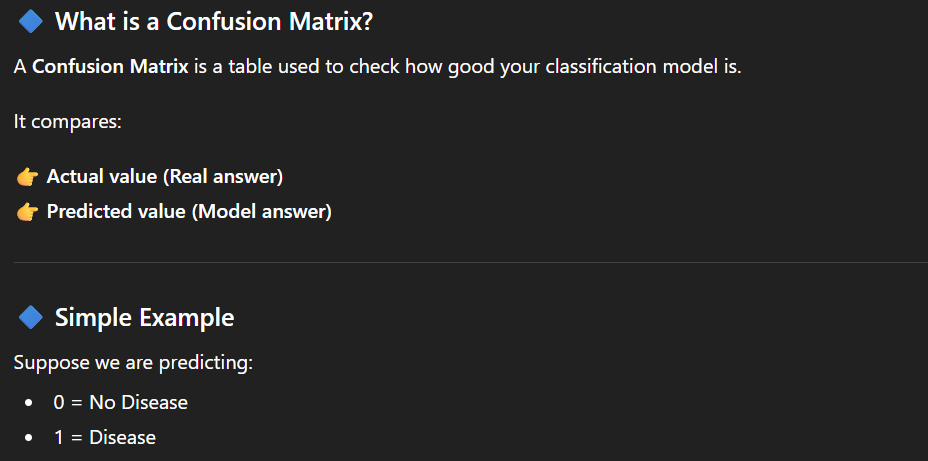

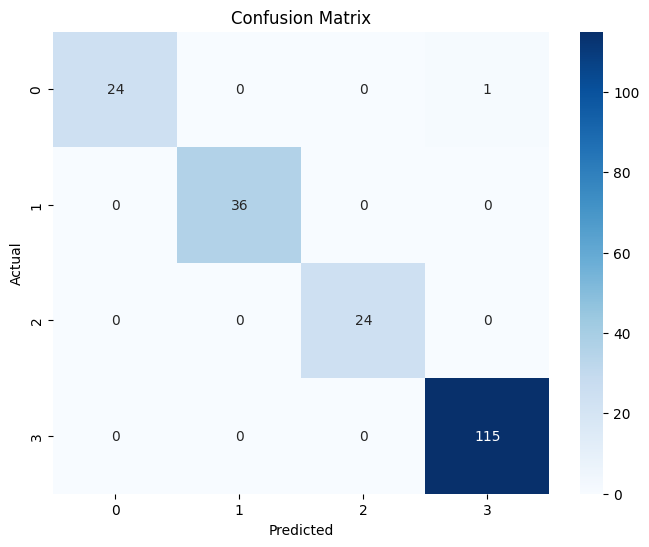

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

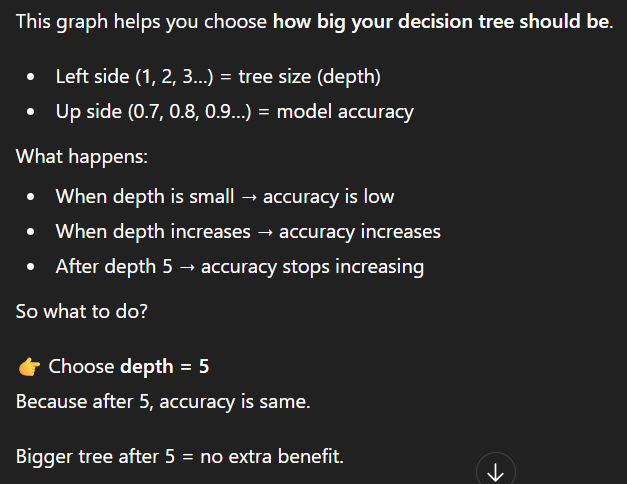

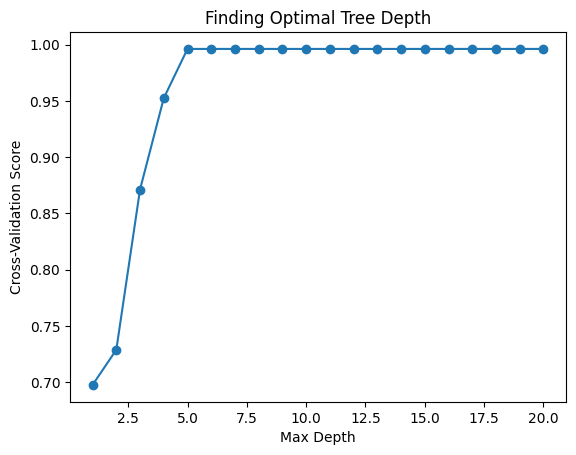

In [ ]:
#The graph tells you the best tree size.
#Here best size is 5

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

depths = range(1, 21)
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, x_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure()
plt.plot(depths, cv_scores, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validation Score')
plt.title('Finding Optimal Tree Depth')
plt.show()

In [ ]:
# Find the best depth based on cv_scores
best_depth_index = cv_scores.index(max(cv_scores))
best_depth = depths[best_depth_index]

best_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=42
)

best_tree.fit(x_train, y_train)

y_train_pred = best_tree.predict(x_train)
y_test_pred = best_tree.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


#recall (positive Class)
print("Train Recall:", recall_score(y_train, y_train_pred, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred, average='weighted'))

print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))

Train Accuracy: 1.0
Test Accuracy: 0.995
Train Recall: 1.0
Test Recall: 0.995
Train Precision: 1.0
Test Precision: 0.9950431034482758


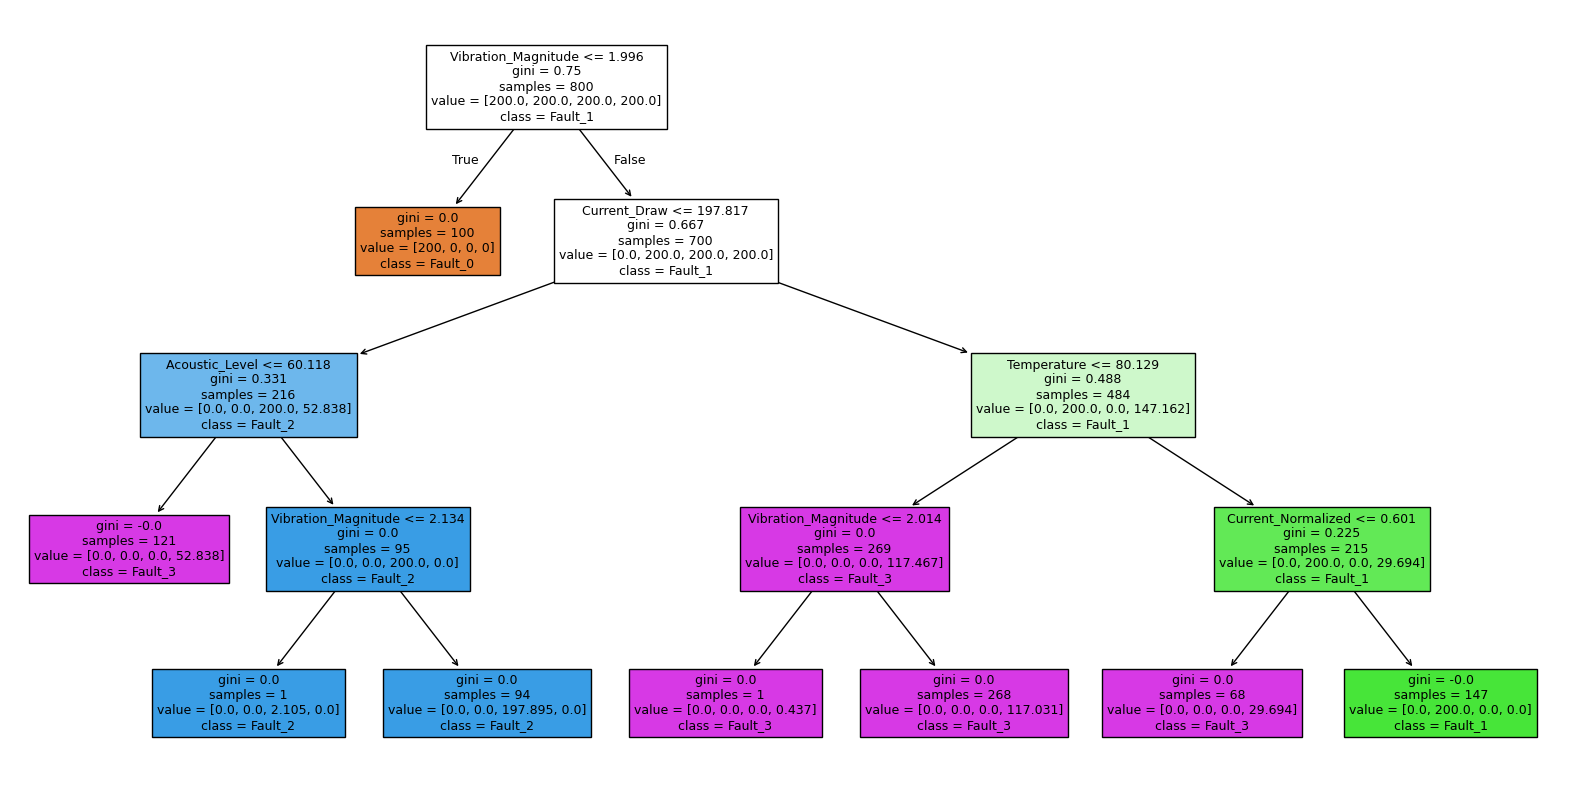

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, feature_names=x.columns, class_names=['Fault_0', 'Fault_1', 'Fault_2', 'Fault_3'], max_depth=4)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, \
average_precision_score
import matplotlib.pyplot as plt

Class 0 - Average Precision: 0.9650
Class 1 - Average Precision: 1.0000
Class 2 - Average Precision: 1.0000
Class 3 - Average Precision: 0.9914


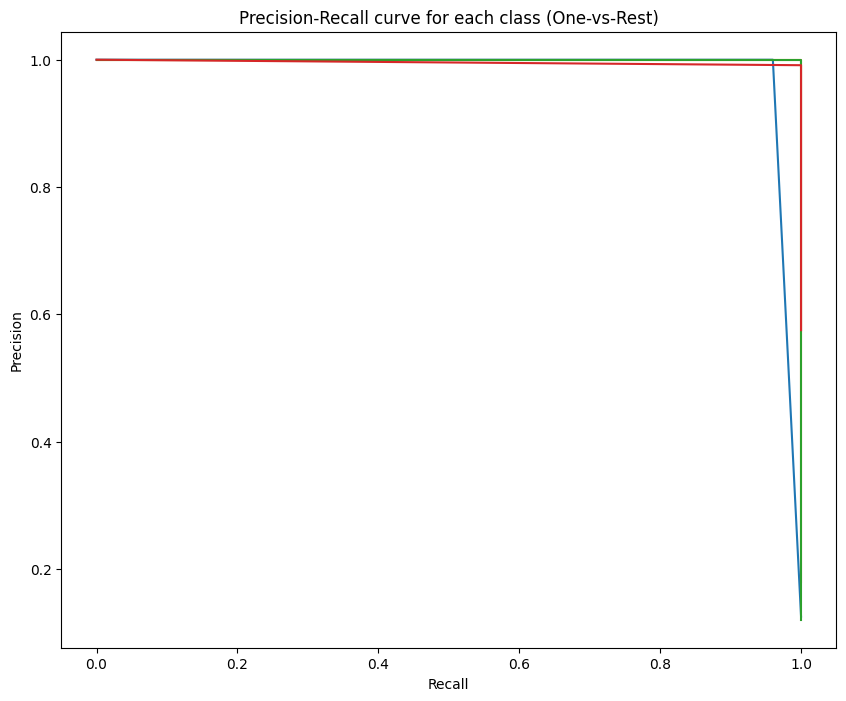

In [ ]:
y_scores = best_tree.predict_proba(x_test)

# Get the number of classes from the model
num_classes = len(best_tree.classes_)

# Calculate Precision-Recall curve and Average Precision for each class
precision = dict()
recall = dict()
thresholds = dict()
avg_precision = dict()

for i in range(num_classes):
    # Binarize y_test for the current class (one-vs-rest)
    y_true_binary = (y_test == best_tree.classes_[i]).astype(int)
    y_score_class = y_scores[:, i]

    precision[i], recall[i], thresholds[i] = precision_recall_curve(y_true_binary, y_score_class)
    avg_precision[i] = average_precision_score(y_true_binary, y_score_class)

    print(f"Class {best_tree.classes_[i]} - Average Precision: {avg_precision[i]:.4f}")

# Optional: Plotting all Precision-Recall curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], label=f'Class {best_tree.classes_[i]} (AP = {avg_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for each class (One-vs-Rest)')
plt.show()